In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter
# import subroutines
# import vis_eulag

plt.style.use('latex_default.mplstyle')

In [2]:
folder = "/work/bd0620/b309199/patagonia"
# folder = "/scratch/b/b309199"

simulations = ["pata_2D_v0", "pata_2D_pha0", "pata_2D_noslip0"]
simulations = ["pata_1D_pha0", "pata_1D_pha1", "pata_1D_tide"]
simulations = ["pata_1D_pha0_mpfl15", "pata_1D_pha1_mpfl15", "pata_1D_tide_mpfl15"]
simulations = ["pata_2D_pha0", "pata_2D_fitzroy", "pata_2D_darwin"]

simulations = ["pata_1D_pha0_mpfl15", "pata_1D_pha1_mpfl15", "pata_1D_tide_mpfl15"]

lidar_sets = []
xz_sets = []
for sim in simulations:
    fpath = os.path.join(folder, sim)
    ds, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars = plt_helper.preprocess_eulag_output(fpath)
    lidar_sets.append(ds_lidars)
    xz_sets.append(ds_xzslices)

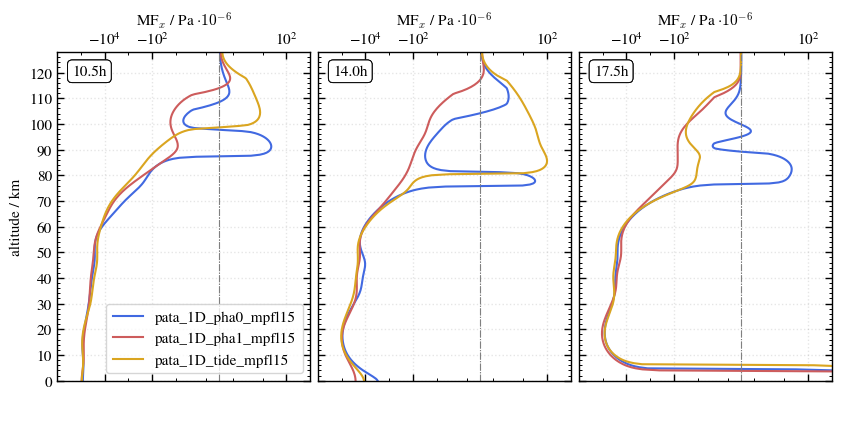

In [60]:
"""Compare vertical profiles of MFx and GWD for different simulations"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [7,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(10,5), gridspec_kw=gskw)
for ax in axes[-1,0:3]:
    ax.set_axis_off()
    
global lambdax, lambdaz
lambdax = 150 * 1000 # m 
lambdaz =  20 * 1000 # m 
zlim = [0,128]
cols = ["royalblue", "indianred", "goldenrod"]
timestamps = [90,120,150]

xrange = [-250*1000, 150*1000]
ix0 = int(xrange[0] / ds.dx00 + ds.nx / 2)
ix1 = int(xrange[1] / ds.dx00 + ds.nx / 2)

for i,sets in enumerate(xz_sets):
    dsxz = sets[0]
    zcr = dsxz['zcr'][0,:,0].values / 1000
    uw  = dsxz['w'].values * (dsxz['u'].values-dsxz['ue'].values)
    mfx_slc = dsxz['rh0'].values * uw
    mfx_slc = np.mean(mfx_slc[:,:,ix0:ix1], axis=2)

    # print(np.shape(mfx_slc))
    for j,t in enumerate(timestamps):
        ax = axes[0,j]
        mfx = mfx_slc[t,:]
        mfx = plt_helper.gaussian_filter_fft_1D(mfx, lambdaz, ds.dz00)
        mfx = mfx * 10**6
        if j == 0:
            ax.plot(mfx, zcr, lw=1.5, ls='-', color=cols[i], label=simulations[i])
        else:
            ax.plot(mfx, zcr, lw=1.5, ls='-', color=cols[i])
        # ax_t.plot(tenv, zcr, lw=1.5, ls='--', color="coral")
        ax.set_xlabel('MF$_x$ / Pa $\cdot 10^{-6}$')
        ax.set_xlim([-10**6,10**3])
        ax.set_xscale("symlog")
        ax.set_xticks([-10**4,-10**2, 10**2])
        ax.vlines(x=[0], ymin=0,ymax=zlim[1], colors="grey", lw=0.75, ls='-.')
        ax.xaxis.set_label_position('top')
        ax.tick_params(which='both', top=True, bottom=True, labelbottom=False, labeltop=True)
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.grid()
        ax.set_ylim(zlim)
        ax.text(0.06,0.93, f"{t * ds.dt00 * ds.nslice / 3600}h", transform=ax.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

axes[0,0].set_ylabel("altitude / km")
axes[0,0].tick_params(which='both', top=True, bottom=True, labelbottom=False, labeltop=True, labelleft=True)
axes[0,0].legend()

fig_title = "xz_profiles_mf_temp.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')
